In [1]:
import os
import pickle
import glob
import skimage
import skimage.transform
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches as ptc
from matplotlib import cm, colors
from tqdm.notebook import tqdm
from os import listdir
from os.path import isfile, join
import shutil, os

import sys

sys.path.append('../../functions')

import chirp_functions as proc
import stmpy

In [2]:
def return_sublat_triangle(origin, coord_crt, lat_vecs, sub_lat_vecs):
    "Enter the coordinates of the atomic site in the unit cell and the origin of the lattice (sublattice 1)."
    "Return the sublattice that the input coordinate belongs to."
    "Only works for triangle lattice. The first lattice vector is the horizontal one, the second is the non-horizontal one."

    # Shift the coordinate to the origin
    rel_coord = np.array(coord_crt) - np.array(origin)

    n2 = rel_coord[1] // lat_vecs[1][1]
    n1 = (rel_coord[0] - n2 * lat_vecs[1][0]) // lat_vecs[0][0]

    frac = rel_coord - n1 * lat_vecs[0] - n2 * lat_vecs[1]

    if np.allclose(frac, sub_lat_vecs[0], atol=1e-1):
        return 0
    elif np.allclose(frac, sub_lat_vecs[1], atol=1):
        return 1
    elif np.allclose(frac, sub_lat_vecs[2], atol=1):
        return 2
    else:
        return -1

In [3]:
x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4
lat_vecs = np.array([[4*x_unit, 0], [-2*x_unit, 2*y_unit]])
sub_lat_vecs = np.array([[-x_unit, y_unit], [0, 0], [x_unit, y_unit]])
coeffs = [0, 0]
coords = coeffs[0] * np.array(lat_vecs[0]) + coeffs[1] * np.array(lat_vecs[1]) + sub_lat_vecs[0]
a = return_sublat_triangle([0,0], coords, lat_vecs, sub_lat_vecs)
print(a)

-1


In [31]:
folder = "../../../data/kagome-02.26.2022-center/"

freq = 4800.0

with open(folder + f"preprocessed_band/_{freq}_0.pkl",'rb') as f:
    real_data = pickle.load(f)

'''
Elements of real_data are assumed to look like:
    0: X in mm
    1: Y in mm
    2: Amplitude
    3: Phase in degrees
'''

sublat_1_data = []
sublat_2_data = []
sublat_3_data = []

lat_vecs = np.array([[4, 0], [2, 2]])
sub_lat_vecs = np.array([[0, 0], [1, 1], [3, 1]])

# Sort the real data into the 3 sublattices
for point in real_data:
    sub_lat = return_sublat_triangle(np.array([0,0]), np.array([point[0], point[1]]), lat_vecs, sub_lat_vecs)

    if sub_lat == 0:
        sublat_1_data.append(point)
    elif sub_lat == 1:
        sublat_2_data.append(point)
    elif sub_lat == 2:
        sublat_3_data.append(point)
    else:
        print('Error: point not in any sublattice', point[0], point[1])

L = 0.01
kxmax = 4*np.pi/(3*np.sqrt(3) * L)
kymax = 2*np.pi/(3*L)
kxs = np.linspace(-2*kxmax, 2*kxmax, 150)
kys = np.linspace(-2*kymax, 2*kymax, 150)

x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4


In [17]:
kxmax/2

np.float64(120.91995761561452)

# No symmetrization

In [37]:

reciprocal_data_1 = np.zeros((len(kxs), len(kys)))
reciprocal_data_2 = np.zeros((len(kxs), len(kys)))
reciprocal_data_3 = np.zeros((len(kxs), len(kys)))
    
for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):
        reciprocal_data_1[yi][xi] = np.abs(np.array(
                [point[2] * np.exp(-1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in sublat_1_data]).sum())
        reciprocal_data_2[yi][xi] = np.abs(np.array(        
                [point[2] * np.exp(-1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in sublat_2_data]).sum())
        reciprocal_data_3[yi][xi] = np.abs(np.array(
                [point[2] * np.exp(-1j * (kxs[xi] * (point[0]*x_unit/1000) + kys[yi] * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                    for point in sublat_3_data]).sum())

reciprocal_data = np.average([reciprocal_data_1, reciprocal_data_2, reciprocal_data_3], axis=0)


  0%|          | 0/150 [00:00<?, ?it/s]

In [19]:
import scipy.ndimage as snd
def sym2d(F, n):
        angle = 360.0/n
        out = np.zeros_like(F)
        for ix in range(n):
            out += snd.rotate(F, angle*ix, reshape=False)
            out += snd.rotate(F, -angle*ix, reshape=False)
        out /= 2*n
        return out

In [20]:
reciprocal_data_sym = stmpy.tools.symmetrize(reciprocal_data, 6, bp=(np.sqrt(3),1), diag=False)
reciprocal_data_rot = sym2d(reciprocal_data, 6)

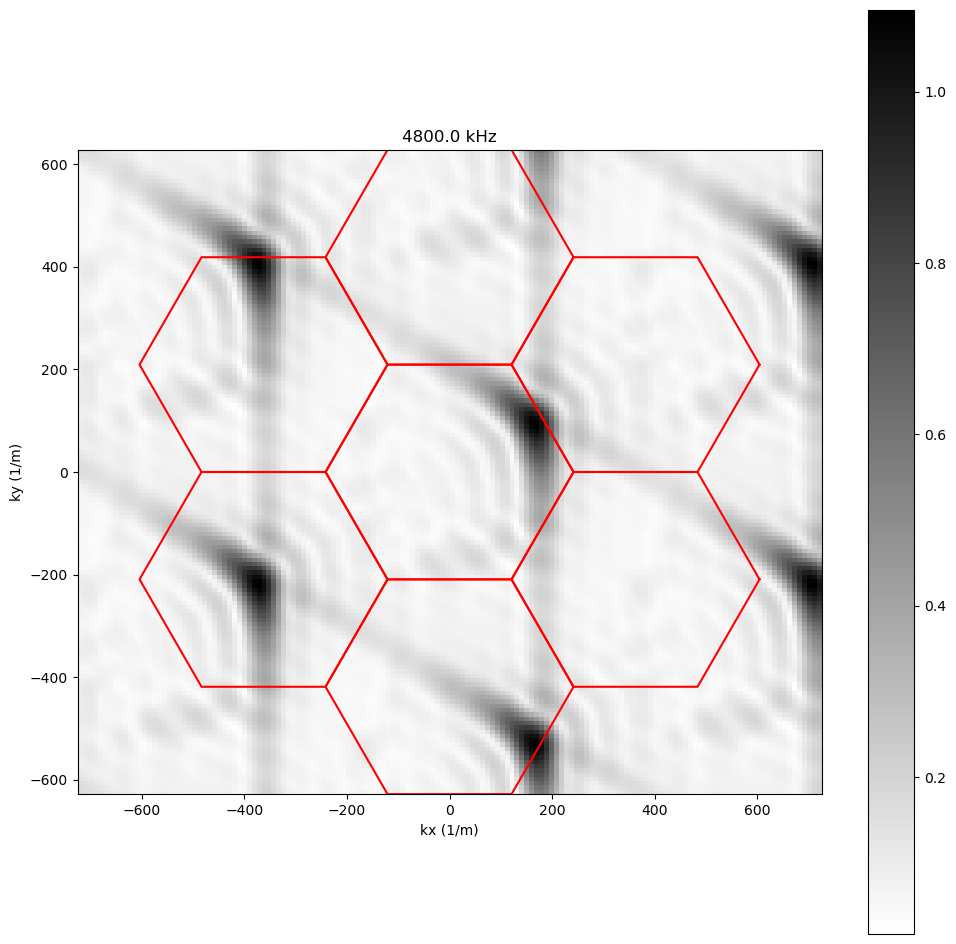

In [38]:

plt.figure(figsize=(12,12))
plt.imshow(reciprocal_data, cmap = 'binary', extent = [-3*kxmax, 3*kxmax, -3*kymax, 3*kymax], aspect = 'equal', origin = 'lower')

xBZ = np.zeros((7,7))
yBZ = np.zeros((7,7))

vec = np.array([[0,0], [np.sqrt(3), 1], [0, 2], [-np.sqrt(3),1], [-np.sqrt(3),-1], [0, -2], [np.sqrt(3),-1]])*kymax
xBZ[0] = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ[0] = [0, kymax, kymax, 0, -kymax, -kymax, 0]

for i in range(7):
    xBZ[i] = xBZ[0] + vec[i][0]
    yBZ[i] = yBZ[0] + vec[i][1]
    plt.plot(xBZ[i], yBZ[i], 'r-')


plt.xlabel("kx (1/m)")
plt.ylabel("ky (1/m)")
plt.title(str(freq)+" kHz")
plt.colorbar()

#plt.savefig(folder + "fourier/figures/2D_DFT_{}Hz.png".format(freq))
plt.show()

# With symmetrization

In [32]:
def mirror_point(pt_coord, line_slope):
    x0 = pt_coord[0]
    y0 = pt_coord[1]

    # first find the angle between the point and the line
    angle = np.arctan2(line_slope, 1) - np.arctan2(y0, x0)

    # then find the mirrored point by rotating (x0, y0) by 2 times the angle
    x1 = x0 * np.cos(2*angle) - y0 * np.sin(2*angle)
    y1 = x0 * np.sin(2*angle) + y0 * np.cos(2*angle)

    return x1, y1

In [33]:
rot_angles = np.linspace(0, 360, 6, endpoint=False) * np.pi / 180

reciprocal_data_1 = np.zeros((len(kys), len(kxs)))
reciprocal_data_2 = np.zeros((len(kys), len(kxs)))
reciprocal_data_3 = np.zeros((len(kys), len(kxs)))

for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):
        
        kxb = kxs[xi]
        kyb = kys[yi]


        # mirror the point (kxb, kyb) about the line y=1/sqrt(3)*x to get kxb_mirr and kyb_mirr
        kxb_mirr, kyb_mirr = mirror_point((kxb, kyb), 1/np.sqrt(3))

        for k in range(len(rot_angles)):
            kxb_crt = kxb * np.cos(rot_angles[k]) - kyb * np.sin(rot_angles[k])
            kyb_crt = kxb * np.sin(rot_angles[k]) + kyb * np.cos(rot_angles[k])
            kxb_mirr_crt = kxb_mirr * np.cos(rot_angles[k]) - kyb_mirr * np.sin(rot_angles[k])
            kyb_mirr_crt = kxb_mirr * np.sin(rot_angles[k]) + kyb_mirr * np.cos(rot_angles[k])

            reciprocal_data_1[yi][xi] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_crt * (point[0]*x_unit/1000) + kyb_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                            for point in sublat_1_data]).sum())
            reciprocal_data_1[yi][xi] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_mirr_crt * (point[0]*x_unit/1000) + kyb_mirr_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                            for point in sublat_1_data]).sum())
            reciprocal_data_2[yi][xi] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_crt * (point[0]*x_unit/1000) + kyb_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                            for point in sublat_2_data]).sum())
            reciprocal_data_2[yi][xi] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_mirr_crt * (point[0]*x_unit/1000) + kyb_mirr_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                            for point in sublat_2_data]).sum())
            reciprocal_data_3[yi][xi] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_crt * (point[0]*x_unit/1000) + kyb_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                            for point in sublat_3_data]).sum())
            reciprocal_data_3[yi][xi] += np.abs(np.array([point[2] * np.exp(-1j * (kxb_mirr_crt * (point[0]*x_unit/1000) + kyb_mirr_crt * (point[1]*y_unit/1000) + (point[3] / 57.2957795131))) 
                            for point in sublat_3_data]).sum())

        reciprocal_data_1[yi][xi] /= len(rot_angles)*2
        reciprocal_data_2[yi][xi] /= len(rot_angles)*2
        reciprocal_data_3[yi][xi] /= len(rot_angles)*2

reciprocal_data = np.average([reciprocal_data_1, reciprocal_data_2, reciprocal_data_3], axis=0)

  0%|          | 0/150 [00:00<?, ?it/s]

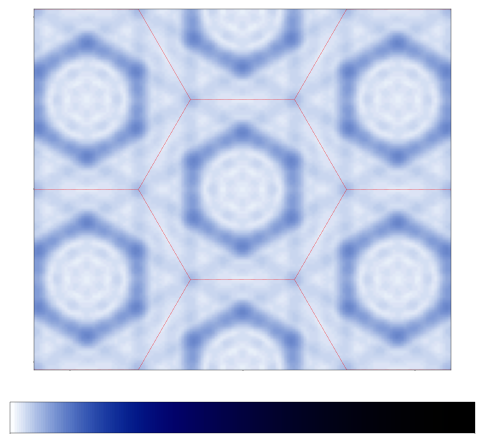

In [34]:

fig, ax = plt.subplots(figsize=(6,6))
plt.imshow(reciprocal_data/3.043,
           extent = [-2*kxmax, 2*kxmax, -2*kymax, 2*kymax], 
           aspect = 'equal', 
           origin = 'lower',
           cmap=stmpy.cm.blue3_r,
           vmax=1,
           vmin=0)


xBZ = np.zeros((7,7))
yBZ = np.zeros((7,7))

vec = np.array([[0,0], [np.sqrt(3), 1], [0, 2], [-np.sqrt(3),1], [-np.sqrt(3),-1], [0, -2], [np.sqrt(3),-1]])*kymax
xBZ[0] = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ[0] = [0, kymax, kymax, 0, -kymax, -kymax, 0]

for i in range(7):
    xBZ[i] = xBZ[0] + vec[i][0]
    yBZ[i] = yBZ[0] + vec[i][1]
    ax.plot(xBZ[i], yBZ[i], 'r:', linewidth=0.25)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)

cb = plt.colorbar(location='bottom', pad=0.07, aspect=15)
# set the length of the colorbar to be 50% of the axis length
cb.set_ticks([0, 1], labels=['',''])
cb.ax.tick_params(labelsize=6.5)
cb.ax.xaxis.set_tick_params(width=0.25, length = 1)
cb.outline.set_linewidth(0.25)
ax.set_xlim([-2*kxmax, 2*kxmax])
ax.set_ylim([-2*kymax, 2*kymax])
ax.set_xticks([-400, 0, 400], ['', '', ''])
ax.set_yticks([-400, 0, 400], ['', '', ''])
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)

fig.savefig("../../../output/paper_new/2D_FT_fig/2D_DFT_{}Hz.pdf".format(freq))

Text(0.5, 1.0, 'Sublattice Coordinates')

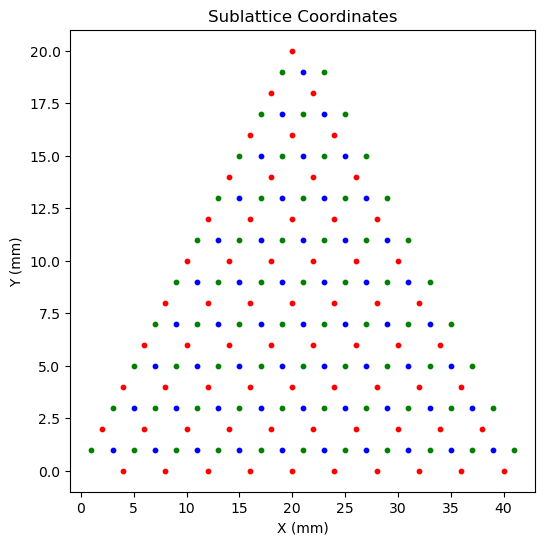

In [35]:
sublat_1_data = np.array(sublat_1_data)
sublat_2_data = np.array(sublat_2_data)
sublat_3_data = np.array(sublat_3_data)

# plot the x and y coordinates of the sublattices
plt.figure(figsize=(6, 6))
plt.scatter(sublat_1_data[:, 0], sublat_1_data[:, 1], c='r', label='Sublattice 1', s=10)
plt.scatter(sublat_2_data[:, 0], sublat_2_data[:, 1], c='g', label='Sublattice 2', s=10)
plt.scatter(sublat_3_data[:, 0], sublat_3_data[:, 1], c='b', label='Sublattice 3', s=10)
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Sublattice Coordinates')

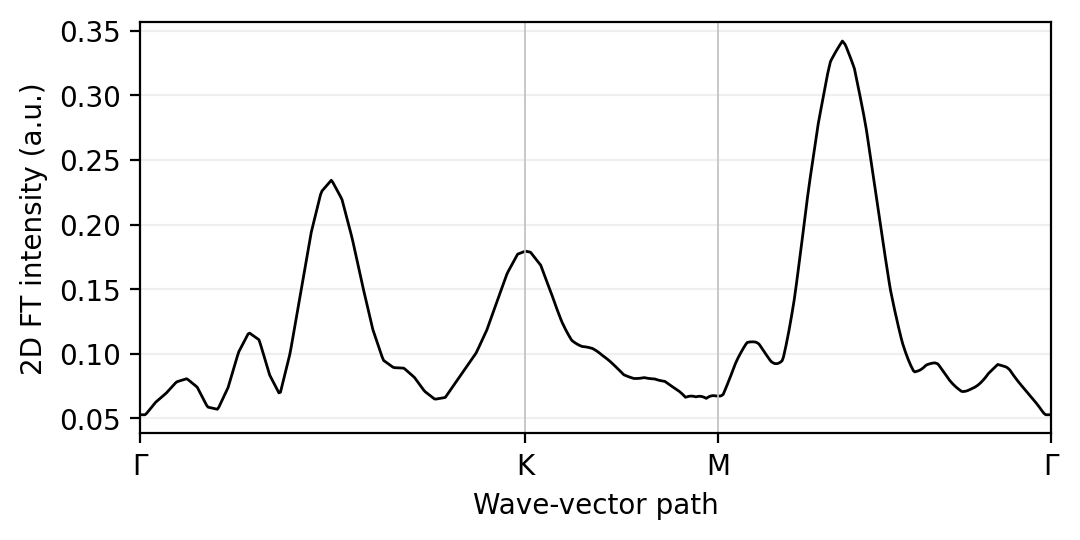

In [36]:
# --- Γ-K-M-Γ sweep in the first Brillouin zone and 2D FT profile ---
# Assumes reciprocal_data, kxmax, kymax are already defined in previous cells.

# High-symmetry points for the hexagonal first BZ used above
G = np.array([0.0, 0.0])
K = np.array([kxmax, 0.0])
M = np.array([0.75 * kxmax, 0.5 * kymax])  # midpoint of edge between K and (0.5*kxmax, kymax)

# Build piecewise-linear path Γ->K->M->Γ
n_per_segment = 250
segments = [(G, K), (K, M), (M, G)]
path_pts = []
for i, (p0, p1) in enumerate(segments):
    t = np.linspace(0, 1, n_per_segment, endpoint=(i == len(segments) - 1))
    seg = (1 - t)[:, None] * p0 + t[:, None] * p1
    path_pts.append(seg)
path_pts = np.vstack(path_pts)

kx_path = path_pts[:, 0]
ky_path = path_pts[:, 1]

# Bilinear interpolation on reciprocal_data defined over extent [-2*kxmax,2*kxmax] x [-2*kymax,2*kymax]
ny, nx = reciprocal_data.shape
x_min, x_max = -2 * kxmax, 2 * kxmax
y_min, y_max = -2 * kymax, 2 * kymax

x_idx = (kx_path - x_min) / (x_max - x_min) * (nx - 1)
y_idx = (ky_path - y_min) / (y_max - y_min) * (ny - 1)

x0 = np.floor(x_idx).astype(int)
y0 = np.floor(y_idx).astype(int)
x1 = np.clip(x0 + 1, 0, nx - 1)
y1 = np.clip(y0 + 1, 0, ny - 1)
x0 = np.clip(x0, 0, nx - 1)
y0 = np.clip(y0, 0, ny - 1)

wx = x_idx - x0
wy = y_idx - y0

I00 = reciprocal_data[y0, x0]
I10 = reciprocal_data[y0, x1]
I01 = reciprocal_data[y1, x0]
I11 = reciprocal_data[y1, x1]

ft_profile = (1 - wx) * (1 - wy) * I00 + wx * (1 - wy) * I10 + (1 - wx) * wy * I01 + wx * wy * I11

# Cumulative path coordinate for x-axis
dk = np.sqrt(np.diff(kx_path)**2 + np.diff(ky_path)**2)
s = np.concatenate([[0], np.cumsum(dk)])

# Tick positions at Γ, K, M, Γ
s_ticks = [0,
           np.linalg.norm(K - G),
           np.linalg.norm(K - G) + np.linalg.norm(M - K),
           s[-1]]

fig, ax = plt.subplots(figsize=(5.5, 2.8), dpi=200)
ax.plot(s, ft_profile, color='k', lw=1)
for st in s_ticks:
    ax.axvline(st, color='0.75', lw=0.6)

ax.set_xticks(s_ticks)
ax.set_xticklabels([r'$\Gamma$', 'K', 'M', r'$\Gamma$'])
ax.set_ylabel('2D FT intensity (a.u.)')
ax.set_xlabel('Wave-vector path')
ax.set_xlim(s[0], s[-1])
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# Plot the correponding real space modes

In [68]:
data_dir = "../../../data/kagome-02.26.2022-center/"
out_dir = "../../../output/paper_new/2D_FT_fig/"

In [74]:
freq = 12

with open(data_dir + f"preprocessed_band/_{int(freq*1e3)}.0_0.pkl",'rb') as f:
    real_data = pickle.load(f) 

preamp_gain = 4.731513 #13.5 dB at minimum gain
mic_gain = 0.02 #0.02V/Pa 
    
amp = real_data[:, 2] /preamp_gain/mic_gain
max_idx = np.argmax(amp)
max_amp_flat = amp[max_idx]
phase = real_data[:, 3] - real_data[max_idx, 3]  # phase relative to the max amplitude
x = real_data[:, 0]
y = real_data[:, 1]
value = amp * np.cos(phase/180 * np.pi)

x_unit = 10*np.sqrt(3)/4
y_unit = 7.5
radius = 3.5

x_coords = x * x_unit
y_coords = y * y_unit

print(max_amp_flat)

0.7668931692674205


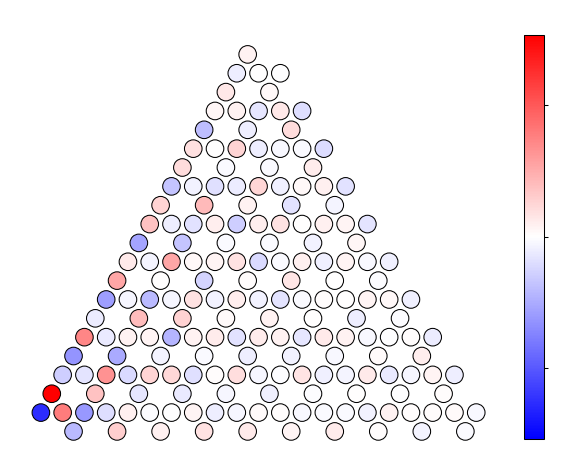

In [76]:
fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(0, 185)
ax.set_ylim(-5, 160)
ax.axis('off')
plt.yticks([])
plt.xticks([])
cbar = fig.colorbar(cm.ScalarMappable(norm=colors.Normalize(vmin=-max_amp_flat, vmax=max_amp_flat), cmap = "bwr"), ax=ax, shrink=0.7)

for i in range(len(x_coords)):

    circle = ptc.Ellipse(
        (x_coords[i], y_coords[i]),
        width=radius*2,
        height=radius*2,
        edgecolor='black',
        facecolor=plt.cm.bwr((value[i] + max_amp_flat) / (2 * max_amp_flat)),
        fill=True,
        alpha=1,
        linewidth=0.25
    )
    ax.add_patch(circle)


cbar.set_ticks(np.linspace(-0.5, 0.5, 3))
cbar.outline.set_linewidth(0.25)
cbar.ax.set_yticklabels(['','',''])
cbar.ax.tick_params(width=0.25, length = 1)
plt.savefig(out_dir + f"amplitude_plot_{freq}kHz.pdf", bbox_inches='tight')